# Métricas e indicadores de calidad
---

## Medición de la calidad de los datos

**¿Qué significa "medir" calidad?**
* Completitud
* Exactitud
* Consistencia
* Validez
* Unicidad
* Actualización (timeliness)

**No se puede mejorar lo que no se mide**
* **Ejemplo simple**
* Dataset de pacientes:
    * % de registros sin DNI -> completitud
    * Edad negativa -> validez
    * Mismo paciente duplicado -> unicidad

**¿Qué problemas de calidad ven?**

| id_paciente | nombre | edad | dni      | fecha_registro |
| --          | --     | --   | --       | --             |
| 1           | Ana    | 25   | 12345678 | 2024-01-10     |
| 2           | Juan   | -5   | 87654321 | 2024-02-15     |
| 3           |        | 40   |          | 2024-13-01     |
| 3           | Carlos | 40   | 87654321 | 2024-02-15     |
| 5           | María  |      | 11223344 |                |
| 6           | Luis   | 30   | 55667788 | 2024-03-20     |
| 7           | Ana    | 25   | 12345678 | 2024-01-10     |

In [8]:
import pandas as pd

In [9]:
df = pd.read_excel('dataset_calidad_datos.xlsx')
df

,id_paciente,nombre,edad,dni,fecha_registro
0,1,Ana,25.0,12345678.0,2024-01-10
1,2,Juan,-5.0,87654321.0,2024-02-15
2,3,NaN,40.0,NaN,2024-13-01
3,3,Carlos,40.0,87654321.0,2024-02-15
4,5,María,NaN,11223344.0,NaN
5,6,Luis,30.0,55667788.0,2024-03-20
6,7,Ana,25.0,12345678.0,2024-01-10


In [10]:
print('Valores nulos:')
df.isnull().sum()

Valores nulos:


id_paciente       0
nombre            1
edad              1
dni               1
fecha_registro    1
dtype: int64

In [11]:
print('Duplicados:')
df[df.duplicated()]

Duplicados:


,id_paciente,nombre,edad,dni,fecha_registro


In [12]:
print('Edades inválidas:')
df[df['edad'] < 0]

Edades inválidas:


,id_paciente,nombre,edad,dni,fecha_registro
1,2,Juan,-5.0,87654321.0,2024-02-15


In [13]:
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'], errors='coerce')
print('Fechas inválidas:')
df[df['fecha_registro'].isnull()]

Fechas inválidas:


,id_paciente,nombre,edad,dni,fecha_registro
2,3,NaN,40.0,NaN,NaT
4,5,María,NaN,11223344.0,NaT


## Indicadores de calidad (DQI)

**DQI (Data Quality Indicator)**: es una métrica cuantificable que refleja el estado de una dimensión de calidad
* **Ejemplos concretos**
    * % de valores nulos
    * % de duplicados
    * % de registros válidos
    * % de consistencia entre sistemas

$$Completitud = \dfrac{valores \; no \; nulos}{total \; de \; valores}$$
$$Duplicados = \dfrac{registros \; duplicados}{total \; de \; registros}$$

**Componentes de un DQI**:
* **Dimensión de calidad**: Ej: completitud, exactitud, consistencia
* **Definición formal**: Qué mide exactamente
* **Fórmula de cálculo**: Cómo se cuantifica
* **Umbral (threshold)**: Qué valor es aceptable
* **Contexto de uso**: Para qué proceso/decisión sirve

**Ejemplo**: **DQI: Completitud de DNI en pacientes**
* **Dimensión**: completitud
* **Definición**: proporción de registros con DNI informado
* **Fórmula**: $\dfrac{registros \; con \; DNI}{total \; de \; registros}$
* **Umbral**: >= 98%
* **Contexto**: identificación única de pacientes

**Dimensiones de calidad más utilizadas**

| Dimensión        | Qué mide                       | Ejemplos de DQI      |
| --               | --                             | --                   |
| **completitud**  | datos faltantes                | % nulos              |
| **exactitud**    | corrección del dato            | % valores correctos  |
| **consistencia** | coherencia entre datos         | % reglas cumplidas   |
| **validez**      | cumplimiento de formato/reglas | % valores válidos    |
| **unicidad**     | no duplicación                 | % registros únicos   |
| **actualidad**   | vigencia temporal              | % datos actualizados |

**Alineación con negocio**
* **Técnico**: % nulos en email = 20%
* **Negocio**: 20% de clientes no pueden ser contactados -> impacto en campañas

**Ciclo de vida de un DQI**
1. Definición
2. Implementación
3. Medición periódica
4. Monitoreo
5. Acción (corrección)

**Sin acción -> no hay gestión de calidad**

## Diseño de métricas alineadas al negocio

**No todas las métricas importan: importan las que impactan en decisiones**

| Ejemplo      | Problema                     | Métrica relevante                                                  |
| --           | --                           | --                                                                 |
| **Salud**    | errores en datos de donantes | % de datos completos en variables críticas (grupo sanguíneo, edad) |
| **RRHH**     | mala calidad en CVs          | % de perfiles con información completa para selección              |
| **Finanzas** | inconsistencias en reportes  | % de registros consistentes entre fuentes                          |

## Visualización de resultados con dashboards

**Un dashboard NO es solo gráfico -> es toma de decisión**
* **Buenas prácticas**:
    * Simplicidad
    * KPIs claros
    * Uso de colores (alertas)
    * Evolución temporal

**Ejemplos de dashboard de calidad**
* % completitud (gauge o barra)
* % duplicados
* tendencia de calidad en el tiempo
* alertas (rojo/verde)

**¿Qué debería tener un dashboard de calidad?**
* KPIs claros -> completitud, duplicados
* Evolución temporal -> tendencias en el tiempo
* Alertas -> soporte a decisión
* Interpretación (no solo gráfico)
* Umbrales -> toma de decisión

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# 1. Dataset simulado
data = {
    'fecha': pd.date_range(start='2024-01-01', periods=10, freq='ME'),
    'total_registros': [100, 120, 110, 130, 125, 140, 150, 160, 155, 170],
    'nulos': [10, 15, 8, 20, 18, 25, 30, 28, 26, 35],
    'duplicados': [5, 6, 4, 7, 6, 8, 10, 9, 8, 11]
}

df = pd.DataFrame(data)

In [21]:
# 2. KPIs de calidad
df['completitud'] = 1 - (df['nulos'] / df['total_registros'])
df['pct_duplicados'] = df['duplicados'] / df['total_registros']

print('Dataset con métricas de calidad')
display(df)

Dataset con métricas de calidad


,fecha,total_registros,nulos,duplicados,completitud,pct_duplicados
0,2024-01-31,100,10,5,0.900000,0.050000
1,2024-02-29,120,15,6,0.875000,0.050000
2,2024-03-31,110,8,4,0.927273,0.036364
3,2024-04-30,130,20,7,0.846154,0.053846
4,2024-05-31,125,18,6,0.856000,0.048000
5,2024-06-30,140,25,8,0.821429,0.057143
6,2024-07-31,150,30,10,0.800000,0.066667
7,2024-08-31,160,28,9,0.825000,0.056250
8,2024-09-30,155,26,8,0.832258,0.051613
9,2024-10-31,170,35,11,0.794118,0.064706


In [22]:
# 3. KPI actuales (último período)
ultimo = df.iloc[-1]

print('KPIs actuales:')
print(f'Completitud: {ultimo['completitud']:.2%}')
print(f'% Duplicados: {ultimo['pct_duplicados']:.2%}')

KPIs actuales:
Completitud: 79.41%
% Duplicados: 6.47%


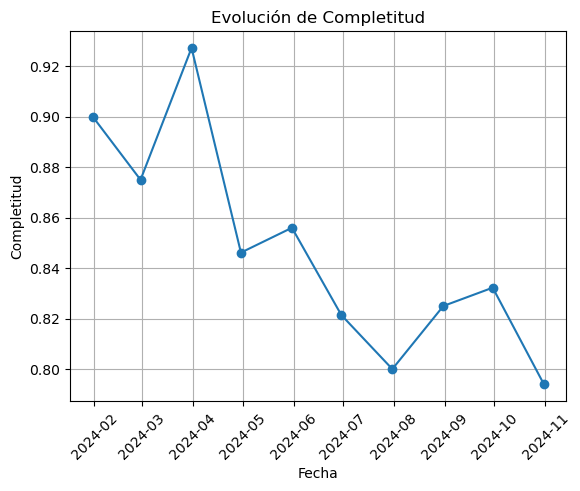

In [23]:
# 4. Dashboard (gráficos)
plt.figure()
plt.plot(df['fecha'], df['completitud'], marker='o')
plt.title('Evolución de Completitud')
plt.xlabel('Fecha')
plt.ylabel('Completitud')
plt.xticks(rotation=45)
plt.grid()
plt.show()

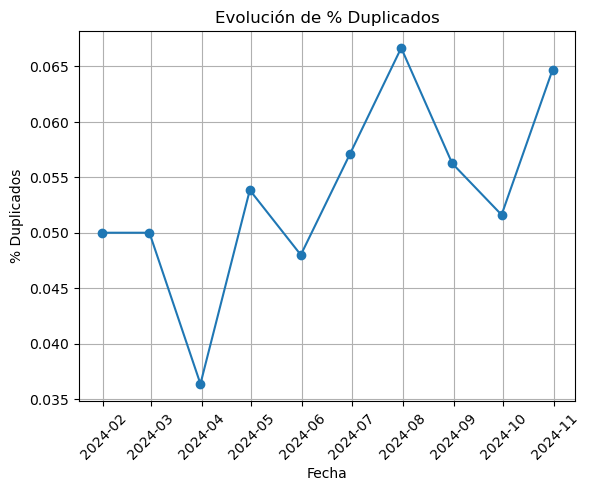

In [24]:
plt.figure()
plt.plot(df['fecha'], df['pct_duplicados'], marker='o')
plt.title('Evolución de % Duplicados')
plt.xlabel('Fecha')
plt.ylabel('% Duplicados')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [25]:
# 5. Alertas simples
umbral_completitud = 0.9
umbral_duplicados = 0.1

print('🚨 Alertas:')

if ultimo['completitud'] < umbral_completitud:
    print('⚠️ Baja completitud detectada')
else:
    print('✅ Completitud OK')

if ultimo['pct_duplicados'] > umbral_duplicados:
    print('⚠️ Alto nivel de duplicados')
else:
    print('✅ Duplicados OK')

🚨 Alertas:
⚠️ Baja completitud detectada
✅ Duplicados OK
